# SmartEdu AI - Notebook 2: Bài toán A và B

Notebook trình bày đại số tuyến tính, khoảng cách, tổ hợp, tương quan, PCA và so sánh mô hình trên dữ liệu học tập theo học kỳ. Hãy chạy `01_data_cleaning.ipynb` trước.

Nhãn mục tiêu: `Target_Dropout_Next_Sem` (1 = rời học ở học kỳ tiếp theo, 0 = không rời học). Đơn vị quan sát là sinh viên-học kỳ, nên một sinh viên có thể có nhiều dòng.

## Lưu ý phương pháp

- ID chỉ để định danh; không đưa vào ma trận feature.
- `End_of_Semester_Status` và `Censored` là cột trạng thái/kết quả, không phải feature dự báo. Bảng chéo ở dưới cho thấy trạng thái `Dropped_Out` khớp hoàn toàn với nhãn 1, nên đưa cột này vào sẽ gây rò rỉ nhãn.
- Phần PCA mô tả (B.2) dùng toàn bộ dữ liệu để minh họa cấu trúc. Riêng đánh giá mô hình (B.3), tách nhóm theo `Student_ID` trước, và fit imputer/scaler/PCA chỉ trên train để tránh cùng sinh viên xuất hiện ở cả train và test, hoặc fit PCA trên test.
- Nhãn mất cân bằng; vì vậy Accuracy không đủ để kết luận. Cần xem thêm Precision, Recall, F1 và confusion matrix.

In [1]:
from pathlib import Path
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
CLEAN_PATH = PROJECT_ROOT / 'data' / 'academic_survival_cleaned.csv'
SOURCE_PATH = PROJECT_ROOT / 'data' / 'academic_survival_longitudinal.csv'
if not CLEAN_PATH.exists():
    raise FileNotFoundError('Hãy chạy 01_data_cleaning.ipynb trước để tạo data/academic_survival_cleaned.csv')
df = pd.read_csv(CLEAN_PATH)
TARGET = 'Target_Dropout_Next_Sem'
ID = 'Student_ID'
print('Dữ liệu sạch: {:,} dòng x {} cột; {:,} sinh viên'.format(len(df), df.shape[1], df[ID].nunique()))
print('Tỷ lệ nhãn:')
display(df[TARGET].value_counts(normalize=True).rename('Tỷ lệ').to_frame())
print('Bảng chéo trạng thái cuối kỳ và nhãn (kiểm tra nguy cơ rò rỉ nhãn):')
display(pd.crosstab(df['End_of_Semester_Status'], df[TARGET]))

Dữ liệu sạch: 79,239 dòng x 22 cột; 20,000 sinh viên
Tỷ lệ nhãn:


,Tỷ lệ
Target_Dropout_Next_Sem,
0,0.912707
1,0.087293


Bảng chéo trạng thái cuối kỳ và nhãn (kiểm tra nguy cơ rò rỉ nhãn):


Target_Dropout_Next_Sem,0,1
End_of_Semester_Status,,
Dropped_Out,0,6917
Enrolled,70354,0
Graduated,1968,0


## A.1 - Dữ liệu sau làm sạch và data dictionary

Bản ghi được đọc từ CSV sạch đã tạo ở Notebook 1. Khóa là `(Student_ID, Semester)`, nên số dòng không bằng số sinh viên duy nhất. `Attendance` được ràng buộc trong [0, 100], `Sem_GPA` trong [0, 4]; dữ liệu số bị khuyết được điền bằng median. Bảng audit ở notebook 1 cho biết chính xác số lỗi và số dòng trước/sau, không nên điền con số suy đoán vào báo cáo.

In [2]:
# Tách danh tính và nhãn. Không đưa ID, nhãn hoặc cột trạng thái vào X.
numeric_features = [
    column for column in df.select_dtypes(include='number').columns
    if column not in {TARGET, 'Censored'}
]
categorical_features = ['Gender', 'Housing_Status']
X = pd.get_dummies(
    df[numeric_features + categorical_features],
    columns=categorical_features,
    drop_first=True,
    dtype=int,
).astype(float)
y = df[TARGET].astype(int)
student_ids = df[ID].copy()

print(f'Ma trận X: {X.shape[0]:,} dòng x {X.shape[1]} feature')
print('Mỗi dòng là một quan sát sinh viên-học kỳ; mỗi cột là một feature số/đã mã hóa.')
print(f'Kiểm tra ID có trong X: {ID in X.columns}')
print(f'Kiểm tra nhãn có trong X: {TARGET in X.columns}')
print('Ba dòng đầu tiên của X:')
display(X.head(3))

# A.2: điểm nguy cơ minh họa bằng tổ hợp tuyến tính trên feature đã chuẩn hóa.
risk_basis = pd.DataFrame({
    'Attendance_deficit': 100 - df['Attendance'],
    'GPA_gap': 4 - df['Sem_GPA'],
    'Failed_Courses': df['Failed_Courses'],
    'Financial_Stress': df['Financial_Stress'],
}, index=df.index)
risk_scaler = StandardScaler()
X_risk = risk_scaler.fit_transform(risk_basis)
w = np.array([0.30, 0.35, 0.20, 0.15])
risk_score = X_risk @ w
print('A.2: X_risk có kích thước', X_risk.shape, 'và w có kích thước', w.shape)
print('Điểm nguy cơ minh họa (không phải xác suất dự báo):')
display(pd.DataFrame({ID: student_ids, 'risk_score': risk_score, TARGET: y}).head(8))
print(f'Tương quan Pearson giữa điểm minh họa và nhãn: {np.corrcoef(risk_score, y)[0, 1]:.3f}')

Ma trận X: 79,239 dòng x 25 feature
Mỗi dòng là một quan sát sinh viên-học kỳ; mỗi cột là một feature số/đã mã hóa.
Kiểm tra ID có trong X: False
Kiểm tra nhãn có trong X: False
Ba dòng đầu tiên của X:


,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,...,Financial_Stress,Gender_Female,Gender_M,Gender_Male,Gender_Other,Gender_Prefer not to say,Gender_female,Gender_male,Housing_Status_On-Campus,Housing_Status_With Parents
0,18.0,0.0,15000.0,2.0,0.0,15000.0,1.0,15.0,18.4,0.0,...,1.7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18.0,0.0,15000.0,2.0,0.0,15000.0,2.0,15.0,23.1,0.0,...,3.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,18.0,0.0,15000.0,2.0,0.0,15000.0,3.0,15.0,19.1,0.0,...,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


A.2: X_risk có kích thước (79239, 4) và w có kích thước (4,)
Điểm nguy cơ minh họa (không phải xác suất dự báo):


,Student_ID,risk_score,Target_Dropout_Next_Sem
0,STU_00001,-0.404654,0
1,STU_00001,0.063384,0
2,STU_00001,0.814043,0
3,STU_00001,1.515059,0
4,STU_00001,1.390432,0
5,STU_00002,0.298584,0
6,STU_00002,0.398168,0
7,STU_00003,-0.595888,0


Tương quan Pearson giữa điểm minh họa và nhãn: 0.296


### Diễn giải A.2

Với ma trận tổng quát `X` có `m` dòng và `n` cột, `X[i, j]` là giá trị feature j của quan sát sinh viên-học kỳ i. Trong minh họa điểm nguy cơ, các cột là Attendance deficit, GPA gap, Failed Courses và Financial Stress; các cột được chuẩn hóa để cùng thang đo. Tích `s = X_risk @ w` tạo một điểm cho mỗi dòng. Trọng số dương làm điểm tăng khi feature bất lợi tăng. Điểm này chỉ minh họa phép tổ hợp tuyến tính, không phải xác suất và không phải mô hình đã được hiệu chỉnh.

In [3]:
# Chọn hai quan sát thuộc hai sinh viên khác nhau và so sánh trên feature đã chuẩn hóa.
first_idx = df.index[0]
second_idx = df.index[df[ID].ne(df.loc[first_idx, ID])][0]
distance_scaler = StandardScaler()
X_scaled = distance_scaler.fit_transform(X)
row_positions = {index: position for position, index in enumerate(X.index)}
first_position = row_positions[first_idx]
second_position = row_positions[second_idx]
first_vector = X_scaled[first_position]
second_vector = X_scaled[second_position]
difference = np.abs(first_vector - second_vector)
euclidean_distance = np.linalg.norm(first_vector - second_vector, ord=2)
manhattan_distance = np.linalg.norm(first_vector - second_vector, ord=1)

first_student = df.loc[first_idx, ID]
first_semester = df.loc[first_idx, 'Semester']
second_student = df.loc[second_idx, ID]
second_semester = df.loc[second_idx, 'Semester']
print('Quan sát A: {}, học kỳ {}'.format(first_student, first_semester))
print('Quan sát B: {}, học kỳ {}'.format(second_student, second_semester))
print('Khoảng cách Euclidean L2: {:.3f}'.format(euclidean_distance))
print('Khoảng cách Manhattan L1: {:.3f}'.format(manhattan_distance))
largest_gaps = pd.Series(difference, index=X.columns).sort_values(ascending=False).head(5)
print('Năm feature đóng góp chênh lệch chuẩn hóa lớn nhất:')
display(largest_gaps.rename('Chênh lệch tuyệt đối sau chuẩn hóa').to_frame())

Quan sát A: STU_00001, học kỳ 1
Quan sát B: STU_00002, học kỳ 1
Khoảng cách Euclidean L2: 6.420
Khoảng cách Manhattan L1: 23.845
Năm feature đóng góp chênh lệch chuẩn hóa lớn nhất:


,Chênh lệch tuyệt đối sau chuẩn hóa
Household_Size,2.250811
Scholarship,2.233276
First_Generation,2.130170
Housing_Status_On-Campus,2.045438
Gender_Male,2.006006


### Diễn giải A.3

Euclidean L2 lấy căn bậc hai tổng bình phương chênh lệch; Manhattan L1 cộng trị tuyệt đối chênh lệch theo từng trục. L1 thường lớn hơn L2 khi có nhiều feature, vì vậy không so sánh trực tiếp độ lớn hai số để kết luận hai sinh viên gần/xa. Bảng trên cho thấy feature nào đóng góp nhiều nhất vào chênh lệch của cặp được chọn. Chuẩn hóa cần thiết khi đơn vị/range khác nhau; nếu không, biến như thu nhập có thể áp đảo khoảng cách. Khoảng cách là nền tảng của KNN, K-Means và phát hiện điểm bất thường; cần cân nhắc mã hóa category và feature thừa trước khi áp dụng.

In [4]:
# A.4: đếm số cách chọn 5 feature từ tập X hiện tại.
n_features = X.shape[1]
k = min(5, n_features)
feature_subsets = math.comb(n_features, k)
print(f'Chọn {k} feature từ {n_features}: C({n_features}, {k}) = {feature_subsets:,} tập')
print('Thử toàn bộ có thể tốn kém khi số feature tăng; nên lọc theo kiến thức nghiệp vụ, variance/correlation/Information Gain,')
print('sau đó đánh giá trên validation hoặc dùng RandomizedSearchCV thay vì chọn theo test set.')

Chọn 5 feature từ 25: C(25, 5) = 53,130 tập
Thử toàn bộ có thể tốn kém khi số feature tăng; nên lọc theo kiến thức nghiệp vụ, variance/correlation/Information Gain,
sau đó đánh giá trên validation hoặc dùng RandomizedSearchCV thay vì chọn theo test set.


## B.1 - Tương quan và tính dư thừa

Dùng tương quan Pearson trên các feature số; loại ID, nhãn và cột trạng thái. Tương quan mô tả liên hệ tuyến tính, không chứng minh quan hệ nhân quả. Các cặp gần |1| có thể mang thông tin trùng lặp và làm hệ số hồi quy kém ổn định hơn, nhưng không nên tự động xóa feature nếu chưa xem ý nghĩa nghiệp vụ.

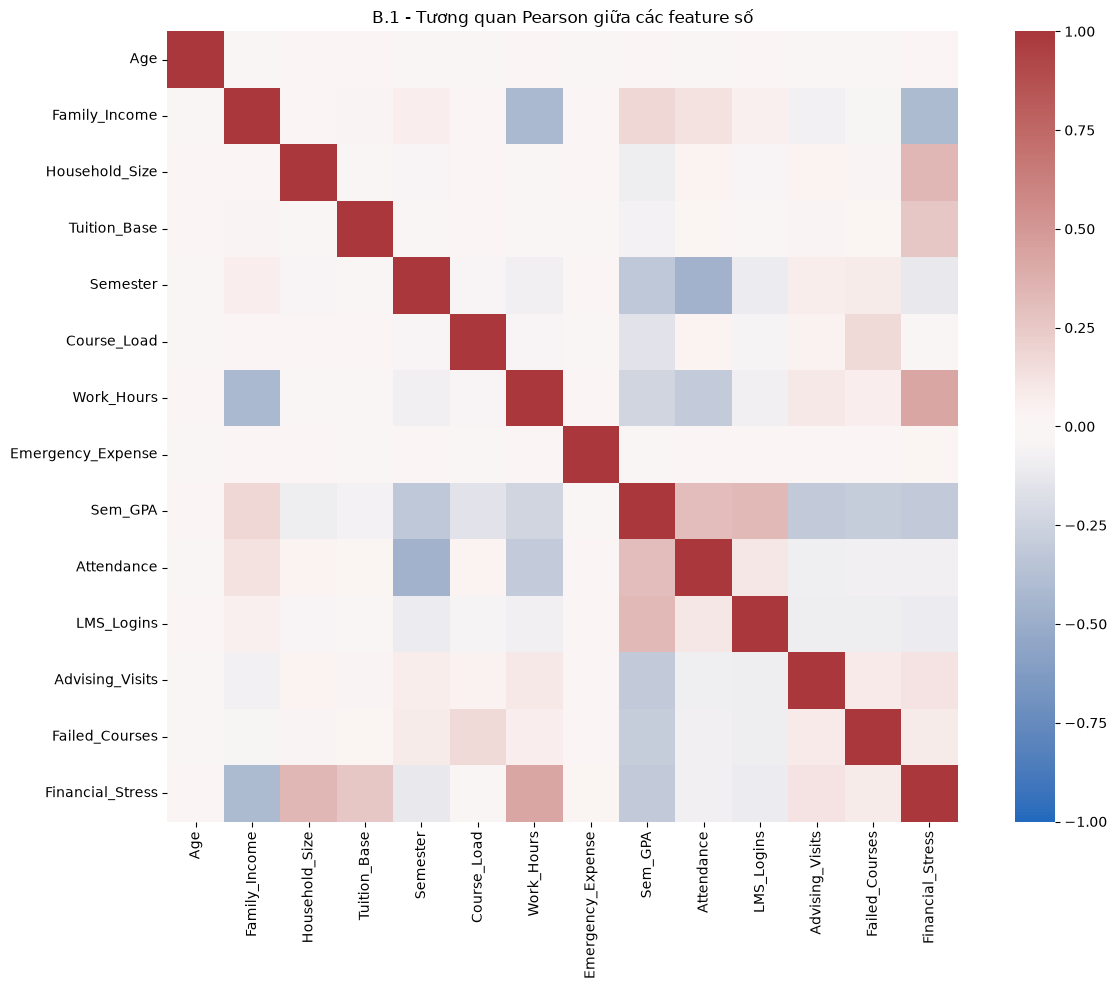

,Đặc trưng 1,Đặc trưng 2,Tương quan,Trị tuyệt đối
0,Semester,Attendance,-0.466955,0.466955
1,Family_Income,Work_Hours,-0.426730,0.426730
2,Work_Hours,Financial_Stress,0.423677,0.423677
3,Family_Income,Financial_Stress,-0.408152,0.408152
4,Household_Size,Financial_Stress,0.339496,0.339496
5,Sem_GPA,LMS_Logins,0.329115,0.329115
6,Semester,Sem_GPA,-0.324519,0.324519
7,Sem_GPA,Financial_Stress,-0.306829,0.306829


In [5]:
correlation_features = [column for column in numeric_features if column not in {'First_Generation', 'Scholarship'}]
correlation_matrix = df[correlation_features].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(correlation_matrix, cmap='vlag', center=0, vmin=-1, vmax=1, square=True)
plt.title('B.1 - Tương quan Pearson giữa các feature số')
plt.tight_layout()
plt.show()

upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
top_pairs = upper_triangle.stack().sort_values(key=lambda values: values.abs(), ascending=False).head(8)
pair_table = pd.DataFrame([{'Đặc trưng 1': left, 'Đặc trưng 2': right, 'Tương quan': value, 'Trị tuyệt đối': abs(value)} for (left, right), value in top_pairs.items()])
display(pair_table)

### Nhận xét B.1

Hãy đọc trị số và dấu của các cặp đầu bảng. |r| gần 1 mới là dấu hiệu mạnh về thông tin tuyến tính trùng lặp; các giá trị vừa phải chưa đủ để kết luận đa cộng tuyến nghiêm trọng. Trong bảng sau làm sạch, cặp nổi bật nhất là Semester và Attendance (r ≈ -0,47); Family_Income và Work_Hours cũng có liên hệ vừa phải (|r| ≈ 0,43). Đây không phải các cặp trùng lặp gần hoàn toàn. Hồi quy tuyến tính có thể có hệ số bất ổn khi các feature gần như phụ thuộc tuyến tính; PCA có thể giảm chiều nhưng làm mất khả năng giải thích theo tên cột gốc.

## B.2 - PCA, trị riêng và trực quan hóa

PCA tìm các trục mới vuông góc sao cho trục đầu tiên giữ nhiều biến thiên nhất. Vector riêng quyết định hướng trục; trị riêng đo lượng phương sai theo hướng đó. PCA không chọn lại cột gốc mà tạo các feature mới là tổ hợp tuyến tính của chúng. Cần chuẩn hóa trước PCA để các đơn vị lớn không chi phối kết quả.

Số feature gốc: 25; số PC cần để đạt ít nhất 80%: 16


,Thành phần,Tỷ lệ phương sai giải thích,Phương sai tích lũy
0,PC1,0.098953,0.098953
1,PC2,0.075676,0.174629
2,PC3,0.067467,0.242096
3,PC4,0.062350,0.304446
4,PC5,0.055163,0.359609
5,PC6,0.047883,0.407492
6,PC7,0.042684,0.450175
7,PC8,0.042047,0.492222
8,PC9,0.040902,0.533124
9,PC10,0.040640,0.573764


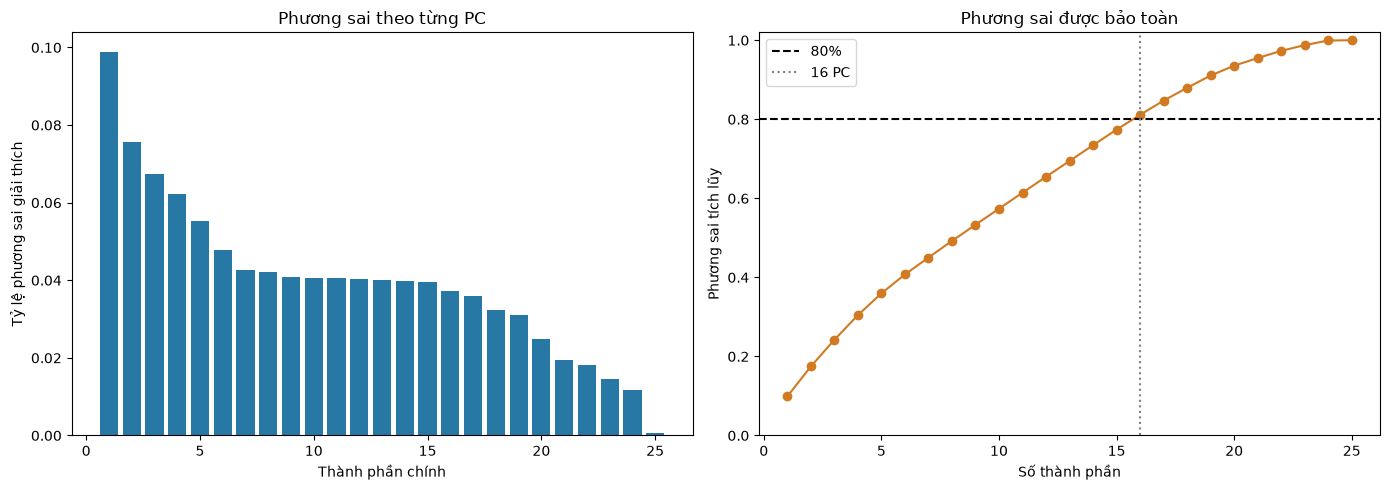

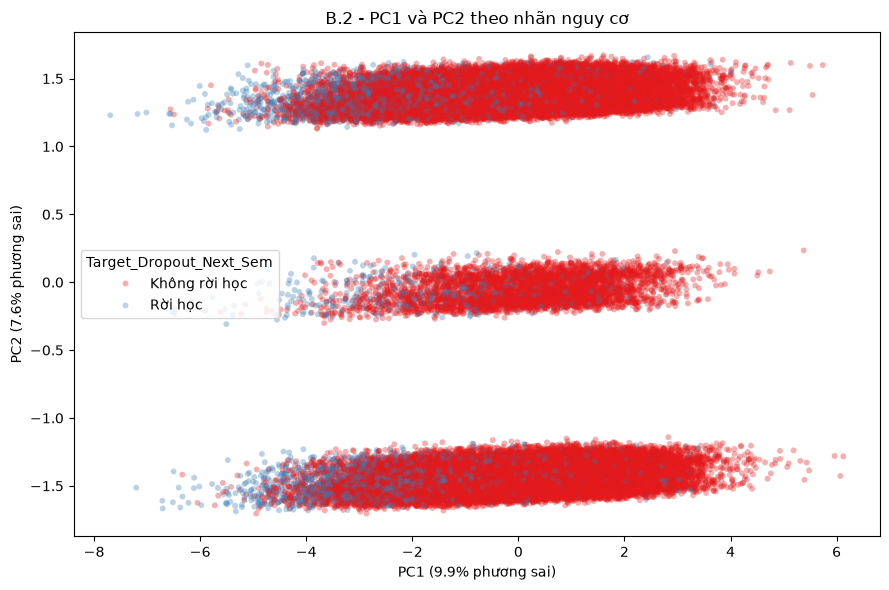

,Số chiều,Diễn giải
Trước PCA,25,"Feature gốc, dễ diễn giải"
Sau PCA (>=80%),16,81.1% phương sai; trực quan hóa PC1-PC2


In [6]:
pca_scaler = StandardScaler()
X_standardized = pca_scaler.fit_transform(X)
pca_full = PCA()
X_pca_all = pca_full.fit_transform(X_standardized)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_components_80 = int(np.searchsorted(cumulative, 0.80) + 1)
variance_table = pd.DataFrame({
    'Thành phần': [f'PC{i + 1}' for i in range(len(explained))],
    'Tỷ lệ phương sai giải thích': explained,
    'Phương sai tích lũy': cumulative,
})
print(f'Số feature gốc: {X.shape[1]}; số PC cần để đạt ít nhất 80%: {n_components_80}')
display(variance_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(np.arange(1, len(explained) + 1), explained, color='#2878A5')
axes[0].set(xlabel='Thành phần chính', ylabel='Tỷ lệ phương sai giải thích', title='Phương sai theo từng PC')
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative, marker='o', color='#D17A22')
axes[1].axhline(0.80, color='black', linestyle='--', label='80%')
axes[1].axvline(n_components_80, color='gray', linestyle=':', label=f'{n_components_80} PC')
axes[1].set(xlabel='Số thành phần', ylabel='Phương sai tích lũy', ylim=(0, 1.02), title='Phương sai được bảo toàn')
axes[1].legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca_all[:, 0], y=X_pca_all[:, 1], hue=y.map({0: 'Không rời học', 1: 'Rời học'}), alpha=0.35, s=18, palette='Set1', linewidth=0)
plt.xlabel(f'PC1 ({explained[0] * 100:.1f}% phương sai)')
plt.ylabel(f'PC2 ({explained[1] * 100:.1f}% phương sai)')
plt.title('B.2 - PC1 và PC2 theo nhãn nguy cơ')
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    'Trước PCA': [X.shape[1], 'Feature gốc, dễ diễn giải'],
    'Sau PCA (>=80%)': [n_components_80, f'{cumulative[n_components_80 - 1] * 100:.1f}% phương sai; trực quan hóa PC1-PC2'],
}, index=['Số chiều', 'Diễn giải']).T)

### Nhận xét B.2

Đọc bảng phương sai để biết từng PC đóng góp bao nhiêu; chọn số PC nhỏ nhất có phương sai tích lũy >= 0,80. Scatter PC1-PC2 chỉ là hình chiếu hai chiều, không đồng nghĩa hai PC này giữ đủ 80%. Nếu các mẫu nguy cơ và không nguy cơ chồng lấn, hai trục đầu không phân tách nhãn tốt; PCA tối ưu phương sai chứ không tối ưu trực tiếp khả năng phân loại. Số feature gốc và số PC được đối chiếu ở bảng cuối cell.

## B.3 - So sánh Logistic Regression trước/sau PCA

Đánh giá bằng một lần chia train/test theo nhóm Student_ID (80/20 gần đúng), để không có bản ghi của cùng sinh viên ở cả hai tập. `Attendance` ngoài miền được đặt lại thành thiếu. Điền khuyết, one-hot encoding và chuẩn hóa được fit trong pipeline chỉ trên train. PCA 80% cũng được fit trên train. Cả hai mô hình dùng cùng Logistic Regression, cùng tập test và `class_weight='balanced'` để giảm ảnh hưởng mất cân bằng nhãn.

Train: 63,475 dòng; test: 15,764 dòng
Số sinh viên train/test: 16,000/4,000; số sinh viên xuất hiện ở cả hai tập: 0
Tỷ lệ nhãn nguy cơ (risk=1) trong test: 8.96%


,Accuracy,Precision (risk=1),Recall (risk=1),F1 (risk=1),Thời gian fit (giây)
model,,,,,
Feature gốc,0.7374,0.2110,0.7054,0.3249,0.2957
PCA >= 80%,0.7158,0.1887,0.6586,0.2934,0.3444


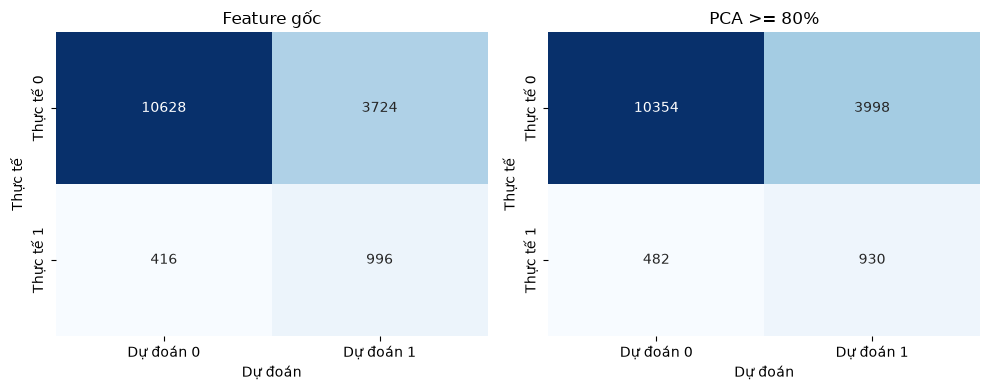

Số feature sau tiền xử lý: 25; số PC được giữ lại: 16;
Phương sai trên train được giữ lại: 81.15%
Thời gian fit chỉ để tham khảo trên máy hiện tại, không phải kết luận tổng quát về tốc độ.
Chênh lệch F1 (PCA - feature gốc): -0.0315
Trên lần chia này, PCA làm giảm F1 risk=1 đáng kể; có thể đã loại bỏ thông tin hữu ích cho nhãn.


In [7]:
if not SOURCE_PATH.exists():
    raise FileNotFoundError(f'Không tìm thấy dữ liệu gốc: {SOURCE_PATH}')
model_df = pd.read_csv(SOURCE_PATH).drop_duplicates().copy()
model_df['Attendance'] = model_df['Attendance'].where(model_df['Attendance'].between(0, 100))
model_df = model_df.dropna(subset=[TARGET])
model_numeric = [column for column in model_df.select_dtypes(include='number').columns if column not in {TARGET, 'Censored'}]
model_categorical = ['Gender', 'Housing_Status']
model_columns = model_numeric + model_categorical
X_raw = model_df[model_columns]
y_raw = model_df[TARGET].astype(int)
groups = model_df[ID]
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(X_raw, y_raw, groups=groups))
X_train, X_test = X_raw.iloc[train_idx], X_raw.iloc[test_idx]
y_train, y_test = y_raw.iloc[train_idx], y_raw.iloc[test_idx]
train_ids = set(groups.iloc[train_idx])
test_ids = set(groups.iloc[test_idx])
assert train_ids.isdisjoint(test_ids)

numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, model_numeric),
    ('categorical', categorical_pipeline, model_categorical),
], sparse_threshold=0)

model_pipelines = {
    'Feature gốc': Pipeline([
        ('preprocess', preprocessor),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
    'PCA >= 80%': Pipeline([
        ('preprocess', preprocessor),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=0.80, svd_solver='full')),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
}

model_results = []
confusion_matrices = {}
for model_name, pipeline in model_pipelines.items():
    started = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started
    predictions = pipeline.predict(X_test)
    confusion_matrices[model_name] = confusion_matrix(y_test, predictions, labels=[0, 1])
    model_results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, predictions),
        'precision_risk_1': precision_score(y_test, predictions, zero_division=0),
        'recall_risk_1': recall_score(y_test, predictions, zero_division=0),
        'f1_risk_1': f1_score(y_test, predictions, zero_division=0),
        'fit_seconds': fit_seconds,
    })
results = pd.DataFrame(model_results).set_index('model')
print('Train: {:,} dòng; test: {:,} dòng'.format(len(train_idx), len(test_idx)))
print('Số sinh viên train/test: {:,}/{:,}; số sinh viên xuất hiện ở cả hai tập: {}'.format(len(train_ids), len(test_ids), len(train_ids & test_ids)))
print(f'Tỷ lệ nhãn nguy cơ (risk=1) trong test: {y_test.mean():.2%}')
display(results.rename(columns={
    'accuracy': 'Accuracy',
    'precision_risk_1': 'Precision (risk=1)',
    'recall_risk_1': 'Recall (risk=1)',
    'f1_risk_1': 'F1 (risk=1)',
    'fit_seconds': 'Thời gian fit (giây)',
}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, (model_name, matrix) in zip(axes, confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis, xticklabels=['Dự đoán 0', 'Dự đoán 1'], yticklabels=['Thực tế 0', 'Thực tế 1'])
    axis.set_title(model_name)
    axis.set_xlabel('Dự đoán')
    axis.set_ylabel('Thực tế')
plt.tight_layout()
plt.show()

pca_model = model_pipelines['PCA >= 80%'].named_steps['pca']
print(f'Số feature sau tiền xử lý: {pca_model.n_features_in_}; số PC được giữ lại: {pca_model.n_components_};')
print(f'Phương sai trên train được giữ lại: {pca_model.explained_variance_ratio_.sum():.2%}')
print('Thời gian fit chỉ để tham khảo trên máy hiện tại, không phải kết luận tổng quát về tốc độ.')

delta_f1 = results.loc['PCA >= 80%', 'f1_risk_1'] - results.loc['Feature gốc', 'f1_risk_1']
print(f'Chênh lệch F1 (PCA - feature gốc): {delta_f1:+.4f}')
if delta_f1 > 0.01:
    print('Trên lần chia này, PCA tăng F1 risk=1 đáng kể; cần lặp lại/CV theo nhóm trước khi kết luận tổng quát.')
elif delta_f1 < -0.01:
    print('Trên lần chia này, PCA làm giảm F1 risk=1 đáng kể; có thể đã loại bỏ thông tin hữu ích cho nhãn.')
else:
    print('Trên lần chia này, F1 gần nhau; chưa thấy lợi ích phân loại đáng kể từ PCA.')

### Kết luận và giải thích kết quả B.3

- So sánh `recall_risk_1` nếu ưu tiên không bỏ sót sinh viên có nguy cơ; so sánh `precision_risk_1` nếu nguồn lực hỗ trợ hạn chế và cần giảm cảnh báo sai. F1 cân bằng hai mục tiêu này. Confusion matrix cho thấy số dương tính/âm tính thật/giả.
- Accuracy cao có thể chỉ phản ánh lớp 0 chiếm ưu thế; hãy xem cùng tỷ lệ risk=1 trong test và các metric của lớp nguy cơ.
- PCA có thể rút gọn đầu vào và giúp mô hình đơn giản hơn, nhưng các PC khó giải thích theo cột nghiệp vụ. Kết quả không mặc định PCA tốt hơn: PCA giữ phương sai tổng thể, có thể loại mất hướng có khả năng dự báo nhãn.
- Thời gian fit phụ thuộc máy và lần chạy; một split chưa đủ để chứng minh tăng tốc độ hay khả năng tổng quát. Nên lặp lại cross-validation theo nhóm sinh viên nếu cần kết luận nghiêm túc.
- Không đưa `Student_ID`, `End_of_Semester_Status`, `Censored` vào feature. Trạng thái kết thúc khớp trực tiếp với nhãn trong bảng chéo; nếu sử dụng sẽ tạo kết quả đẹp giả tạo do rò rỉ nhãn.

## Tóm tắt A và B

Notebook đã tách ID/nhãn, minh họa `X @ w`, tính L1/L2 sau chuẩn hóa, đếm không gian chọn feature, vẽ tương quan, báo cáo phương sai PCA và so sánh Logistic Regression trước/sau PCA trên test theo nhóm sinh viên. Hãy đưa các bảng và biểu đồ đã sinh cùng các metric thực tế vào báo cáo; nếu dataset hoặc split thay đổi thì không sử dụng lại con số cũ.